<h1 style='color:green'>K-Means Clustering</h1>

## Let's know the idea about K-Means Clustering

[View the PDF](./009-K-Means-Clustering.pdf)

In [4]:
from IPython.display import IFrame
IFrame('009-K-Means-Clustering.pdf', width=650, height=650)

##### K-Means is an example of Hard Clustering, where every point belongs only to one cluster

In [6]:
#Data Preparation 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs

In [7]:
X, y = make_blobs(n_samples=500, n_features=2, centers=5, random_state=3)
m = X.shape[0]
n_features = X.shape[1]

In [8]:
print(X.shape)

(500, 2)


In [9]:
# Not really needed -> because of unsupervised learning 
np.unique(y)

array([0, 1, 2, 3, 4])

In [10]:
# Data Normalise 
def Normalise(X): 
    u = X.mean(axis=0)
    std = X.std(axis=0) 
    return (X-u)/std  
X = Normalise(X)

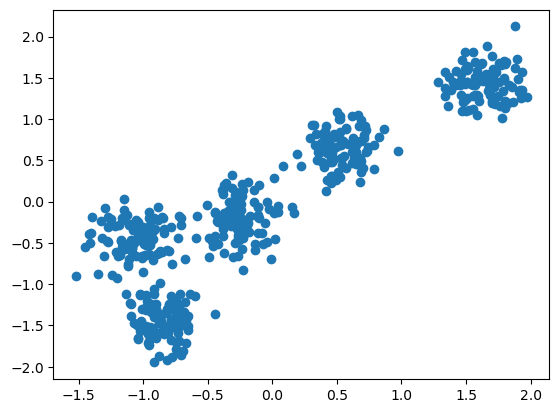

In [11]:
# Data Visualise 
plt.scatter(X[:,0],X[:,1])
plt.show()

### Step-1

In [13]:
# Init the K-centers for k clusters  
k = 5 
colors = ["green", "red", "blue", "yellow", "orange"]

def init(k): 
    centroids={}
    
    for i in range(k):
        center = 2*(2*np.random.random((n_features,))-1) # value between -2 to 2 
        centroids[i]={
            'center' : center,
            'color' : colors[i], 
            'points' : []
        }
    return centroids


In [14]:
#print(centroids)

### Step-2

In [16]:

def distance(p,q): 
    return np.sqrt(np.sum((p-q))**2)

def assignPtsToCluster(X, centroids): 
    # Each point will be assigned to exactly one of the clusters 
    for i in range(m):
        cdist = [] 
        # Find the distance of current point from each centeroid 
        for j in range(k):
            d = distance(centroids[j]['center'], X[i])
            cdist.append(d) 
       
        clusterId = np.argmin(cdist)
        centroids[clusterId]['points'].append(X[i])

In [17]:
#assignPtsToCluster(X, centroids)

In [18]:
#centroids

### Step-3 

In [20]:
def updateClusters(centroids): 
    
    #Update Every centroids by taking a mean of points assigned to the cluster 
    for i in range(k):
        pts = np.array(centroids[i]['points'])

        if pts.shape[0] > 0: 
            newCenter = pts.mean(axis=0)
            centroids[i]['center'] = newCenter
            centroids[i]['points'] = [] #Clear the list for step 2

In [21]:
def plotClusters(centroids): 
    for i in range(k):
        pts = np.array(centroids[i]['points'])
        if(pts.shape[0]>0): 
            plt.scatter(pts[:,0], pts[:,1], color=centroids[i]['color'])

        center = centroids[i]['center']
        plt.scatter(center[0],center[1],color='black', marker='*')

In [22]:
centroids = init(k)

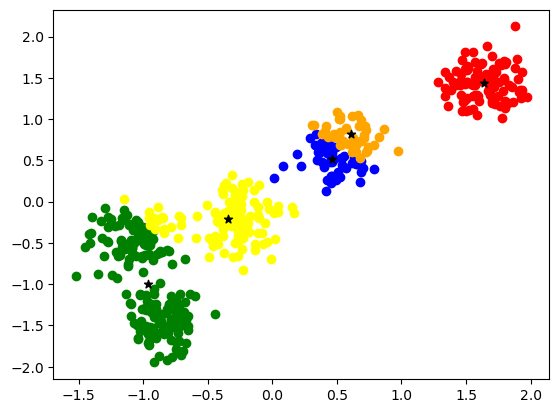

In [74]:
# Run again and again until get better cluster 
assignPtsToCluster(X, centroids)
plotClusters(centroids)
updateClusters(centroids)